<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install pandas
!pip install matplotlib


import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 110.1 MB/s eta 0:00:00


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




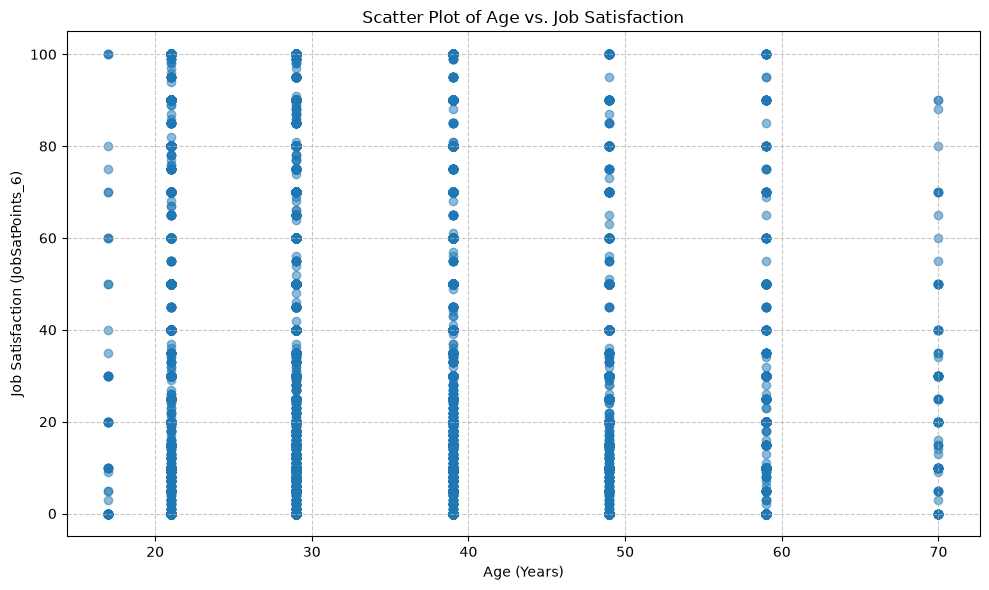

In [4]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Age, JobSatPoints_6
FROM main
WHERE Age IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

ages = []
jobsat = []


for age, sat in rows:
    try:
        if age in age_mapping:
            ages.append(age_mapping[age])
            jobsat.append(float(sat))
    except (ValueError, TypeError):
        continue
        
plt.figure(figsize=(10, 6))

plt.scatter(
    ages,
    jobsat,
    alpha=0.5
)

plt.title("Scatter Plot of Age vs. Job Satisfaction")
plt.xlabel("Age (Years)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


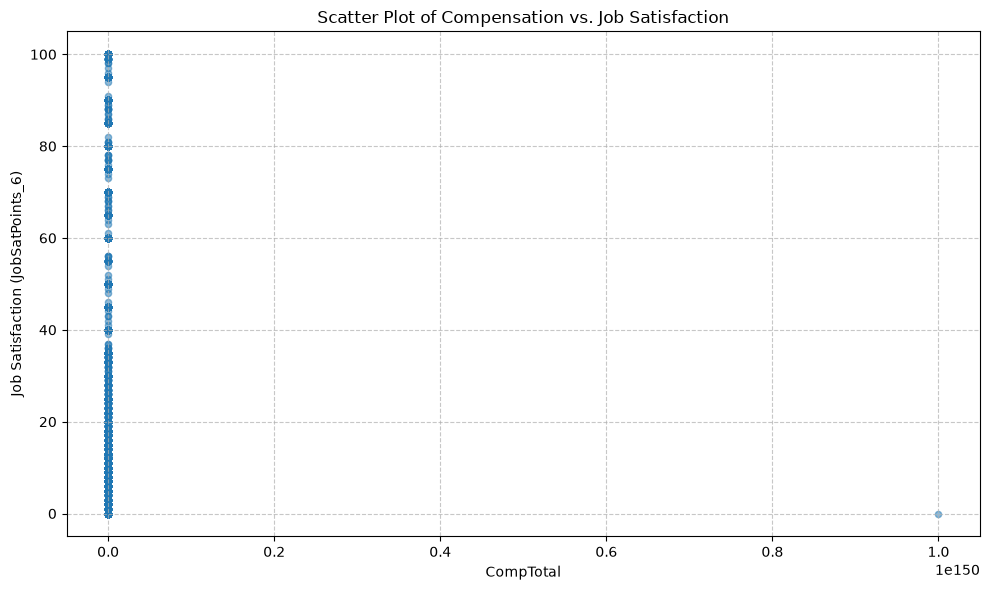

In [5]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

compensation = []
job_satisfaction = []

for comp, sat in rows:
    try:
        comp = float(comp)
        sat = float(sat)

        if comp > 0:
            compensation.append(comp)
            job_satisfaction.append(sat)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(10, 6))

plt.scatter(
    compensation,
    job_satisfaction,
    alpha=0.5,
    s=20
)

plt.title("Scatter Plot of Compensation vs. Job Satisfaction")
plt.xlabel("CompTotal")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


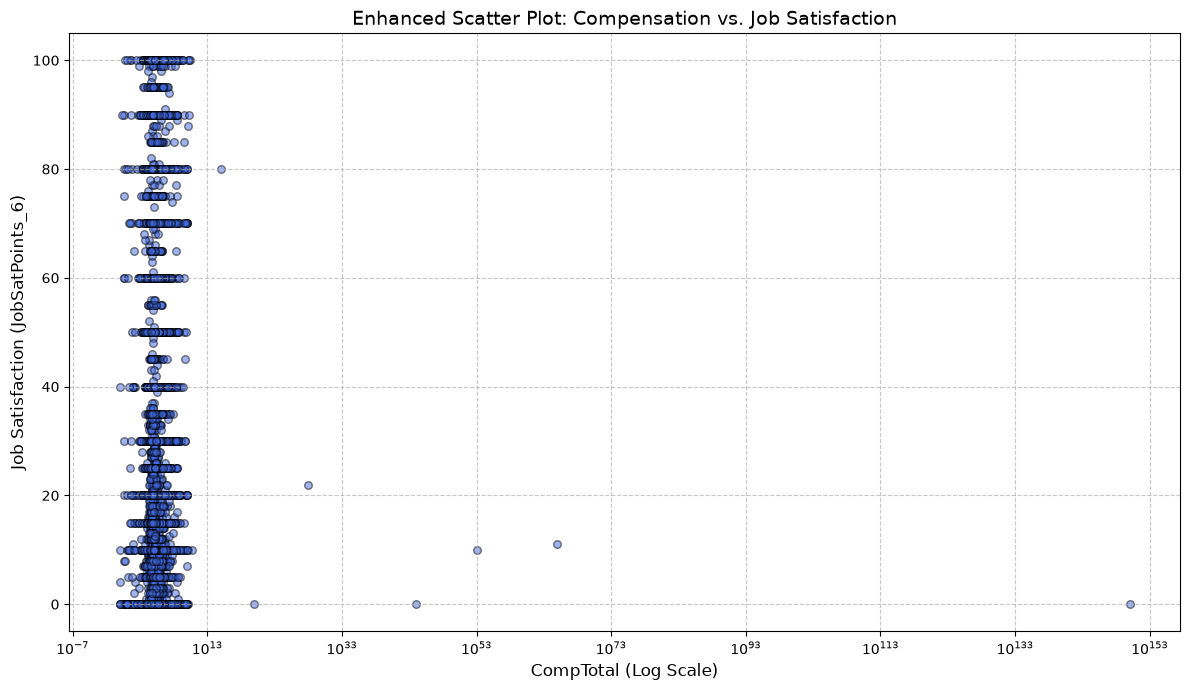

In [6]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

compensation = []
job_satisfaction = []

for comp, sat in rows:
    try:
        comp = float(comp)
        sat = float(sat)

     
        if comp > 0:
            compensation.append(comp)
            job_satisfaction.append(sat)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 7))


plt.scatter(
    compensation,
    job_satisfaction,
    color="royalblue",
    marker="o",
    s=30,
    alpha=0.5,
    edgecolors="black"
)


plt.xscale("log")

plt.title("Enhanced Scatter Plot: Compensation vs. Job Satisfaction", fontsize=14)
plt.xlabel("CompTotal (Log Scale)", fontsize=12)
plt.ylabel("Job Satisfaction (JobSatPoints_6)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


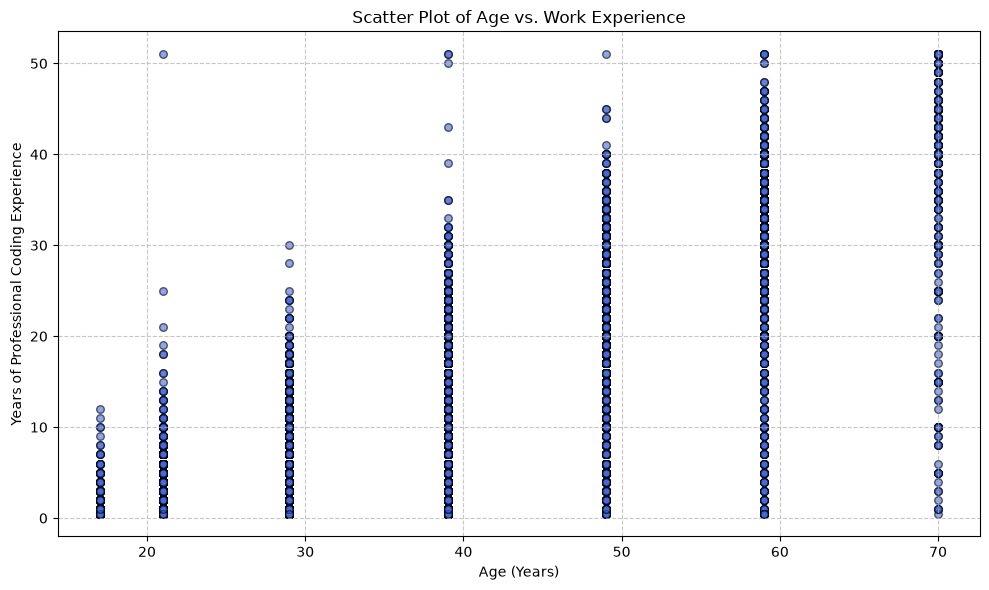

In [7]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Age, YearsCodePro
FROM main
WHERE Age IS NOT NULL
AND YearsCodePro IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

ages = []
experience = []

for age, years in rows:
    try:
        
        if age not in age_mapping:
            continue
        age_num = age_mapping[age]

       
        if years == "Less than 1 year":
            years_num = 0.5
        elif years == "More than 50 years":
            years_num = 51
        else:
            years_num = float(years)

        ages.append(age_num)
        experience.append(years_num)

    except (ValueError, TypeError):
        continue


plt.figure(figsize=(10, 6))

plt.scatter(
    ages,
    experience,
    color="royalblue",
    marker="o",
    s=30,
    alpha=0.6,
    edgecolors="black"
)

plt.title("Scatter Plot of Age vs. Work Experience")
plt.xlabel("Age (Years)")
plt.ylabel("Years of Professional Coding Experience")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


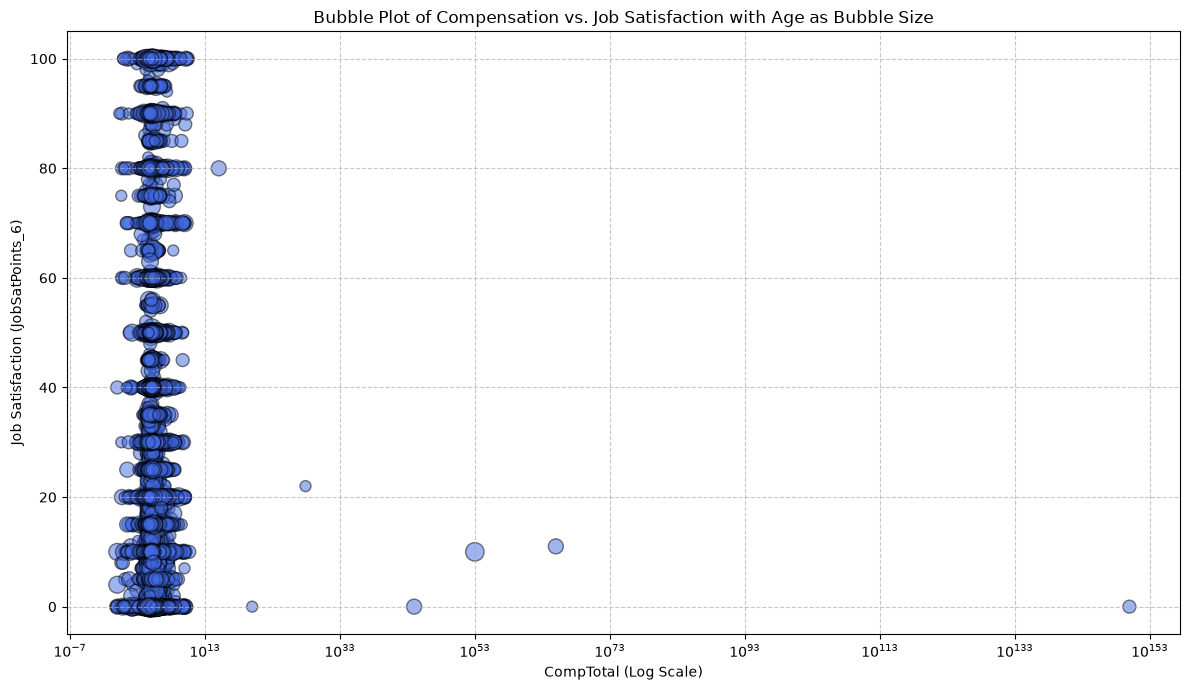

In [8]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT CompTotal, JobSatPoints_6, Age
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
AND Age IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

compensation = []
job_satisfaction = []
bubble_sizes = []

for comp, sat, age in rows:
    try:
        comp = float(comp)
        sat = float(sat)

        if comp <= 0 or age not in age_mapping:
            continue

        compensation.append(comp)
        job_satisfaction.append(sat)

  
        bubble_sizes.append(age_mapping[age] * 3)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 7))

plt.scatter(
    compensation,
    job_satisfaction,
    s=bubble_sizes,    
    alpha=0.5,
    color="royalblue",
    edgecolors="black"
)


plt.xscale("log")

plt.title("Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size")
plt.xlabel("CompTotal (Log Scale)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


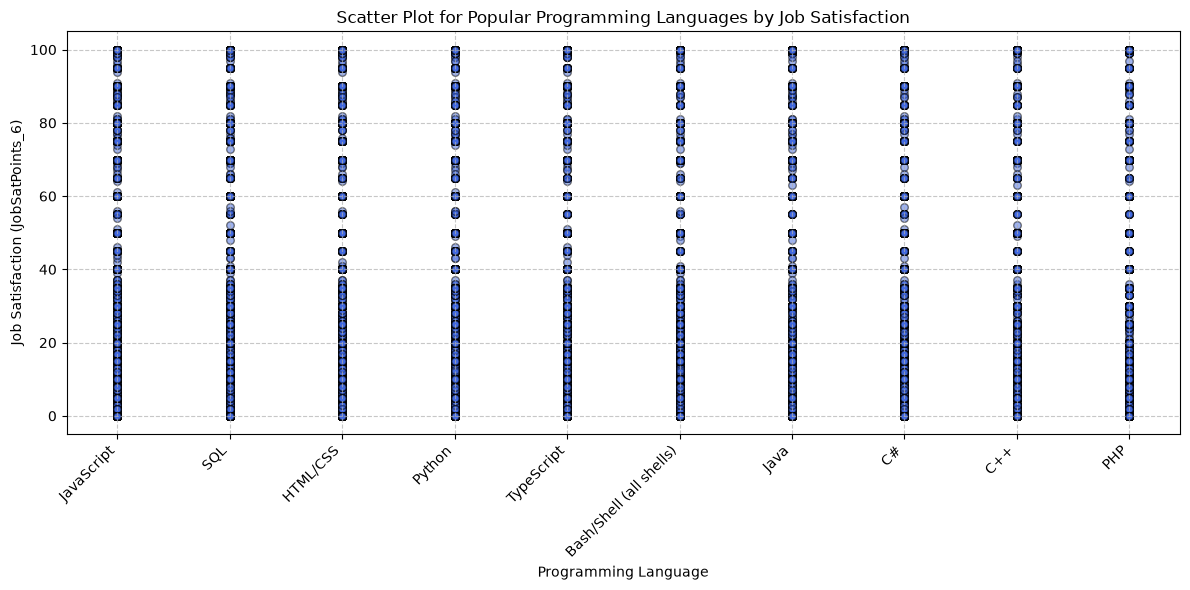

In [9]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT LanguageHaveWorkedWith, JobSatPoints_6
FROM main
WHERE LanguageHaveWorkedWith IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

language_counter = Counter()

for languages, _ in rows:
    for lang in languages.split(";"):
        language_counter[lang.strip()] += 1

top_languages = [lang for lang, count in language_counter.most_common(10)]

language_positions = {lang: i for i, lang in enumerate(top_languages)}

x = []
y = []


for languages, jobsat in rows:
    try:
        jobsat = float(jobsat)

        for lang in languages.split(";"):
            lang = lang.strip()

            if lang in language_positions:
                x.append(language_positions[lang])
                y.append(jobsat)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    color="royalblue",
    alpha=0.5,
    s=30,
    edgecolors="black"
)

plt.title("Scatter Plot for Popular Programming Languages by Job Satisfaction")
plt.xlabel("Programming Language")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")

plt.xticks(
    ticks=range(len(top_languages)),
    labels=top_languages,
    rotation=45,
    ha="right"
)

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


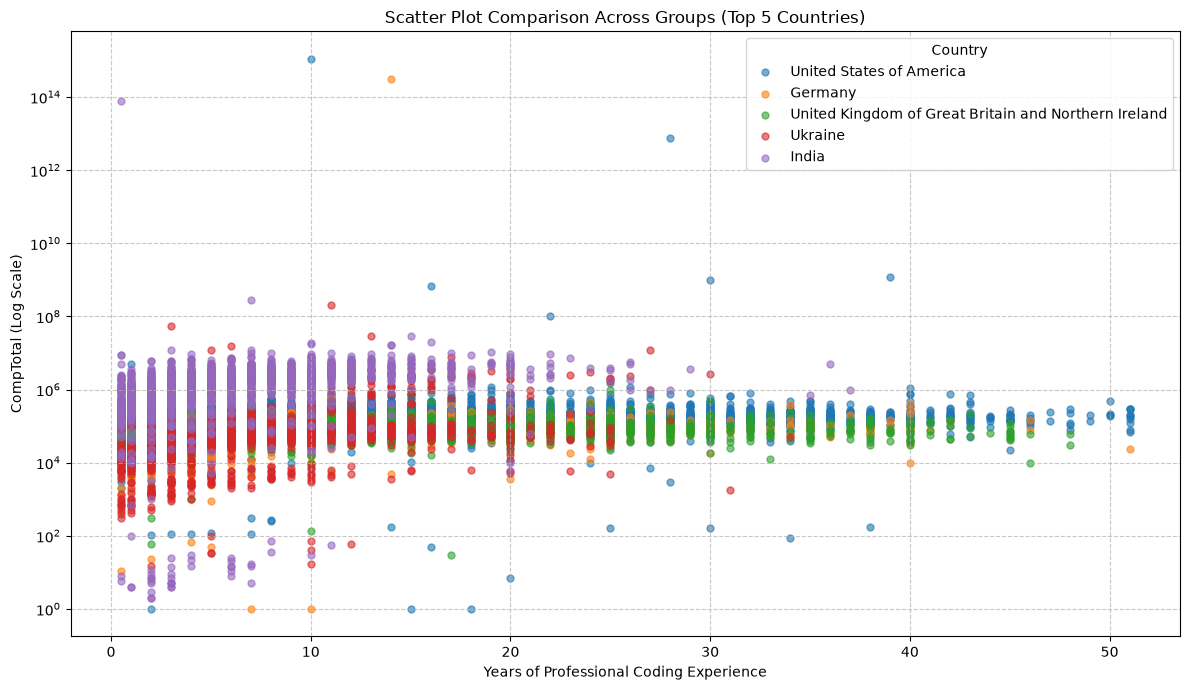

In [10]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Country, YearsCodePro, CompTotal
FROM main
WHERE Country IS NOT NULL
AND YearsCodePro IS NOT NULL
AND CompTotal IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

country_counter = Counter()

for country, _, _ in rows:
    country_counter[country] += 1

top5_countries = [country for country, count in country_counter.most_common(5)]

country_data = {country: {"x": [], "y": []} for country in top5_countries}

for country, years, comp in rows:
    if country not in top5_countries:
        continue

    try:
        if years == "Less than 1 year":
            years = 0.5
        elif years == "More than 50 years":
            years = 51
        else:
            years = float(years)

        comp = float(comp)

        if comp > 0:
            country_data[country]["x"].append(years)
            country_data[country]["y"].append(comp)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 7))

for country in top5_countries:
    plt.scatter(
        country_data[country]["x"],
        country_data[country]["y"],
        s=25,
        alpha=0.6,
        label=country
    )

plt.yscale("log")

plt.title("Scatter Plot Comparison Across Groups (Top 5 Countries)")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("CompTotal (Log Scale)")


plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Country")

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


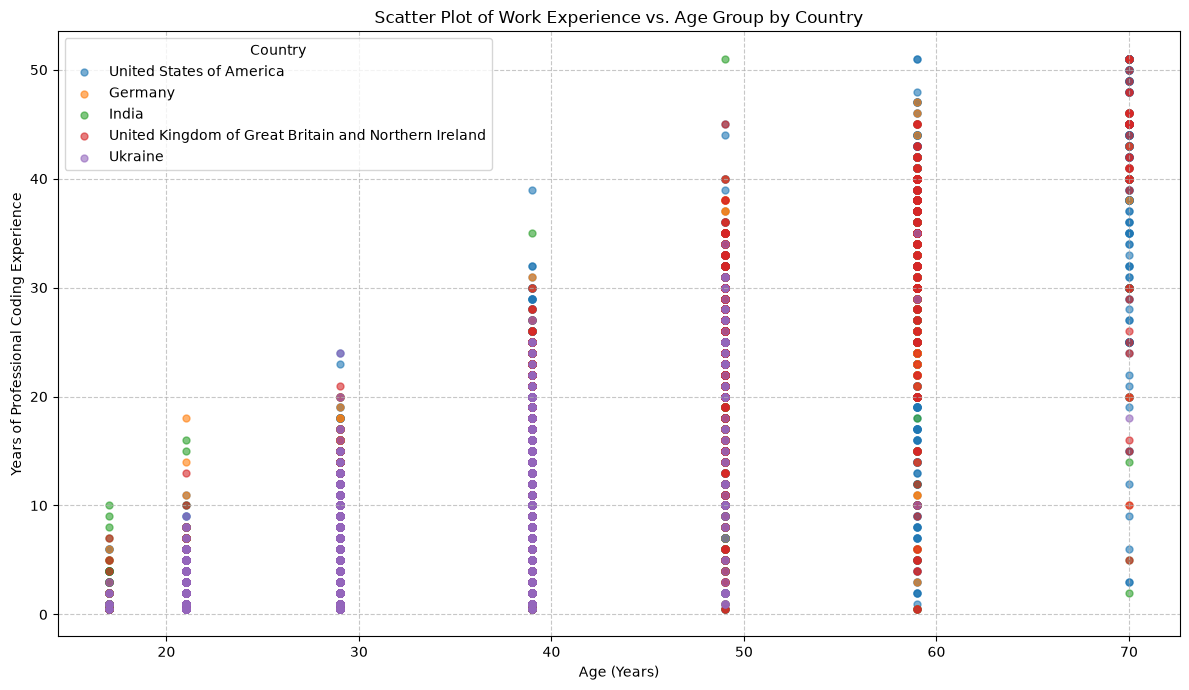

In [11]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Country, Age, YearsCodePro
FROM main
WHERE Country IS NOT NULL
AND Age IS NOT NULL
AND YearsCodePro IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}


country_counter = Counter()

for country, _, _ in rows:
    country_counter[country] += 1

top5_countries = [country for country, count in country_counter.most_common(5)]

country_data = {
    country: {"age": [], "experience": []}
    for country in top5_countries
}


for country, age, years in rows:
    if country not in top5_countries:
        continue

    try:
        
        if age not in age_mapping:
            continue
        age_num = age_mapping[age]

     
        if years == "Less than 1 year":
            years_num = 0.5
        elif years == "More than 50 years":
            years_num = 51
        else:
            years_num = float(years)

        country_data[country]["age"].append(age_num)
        country_data[country]["experience"].append(years_num)

    except (ValueError, TypeError):
        continue

plt.figure(figsize=(12, 7))

for country in top5_countries:
    plt.scatter(
        country_data[country]["age"],
        country_data[country]["experience"],
        s=25,
        alpha=0.6,
        label=country
    )

plt.title("Scatter Plot of Work Experience vs. Age Group by Country")
plt.xlabel("Age (Years)")
plt.ylabel("Years of Professional Coding Experience")

plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Country")

plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
